# Ensemble Learning & Advanced ML Techniques

### Ensemble

In [6]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X,y=load_wine(return_X_y=True)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    random_state=42)

### Bagging

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag=BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [8]:
from sklearn.metrics import accuracy_score

pred=bag.predict(X_test)

print(accuracy_score(y_test,pred))

0.9722222222222222


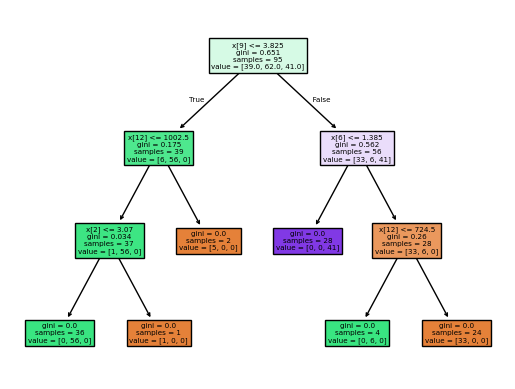

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(
bag.estimators_[0],
filled=True)
plt.show()

### Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
n_estimators=200,
max_depth=8,
random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [11]:
pred=rf.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(
y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



<Axes: >

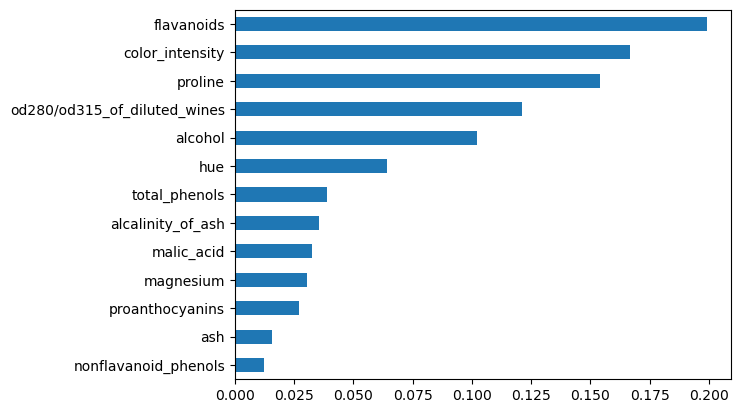

In [13]:
import pandas as pd

importance=pd.Series(
rf.feature_importances_,
index=load_wine().feature_names)

importance.sort_values().plot.barh()

In [14]:
from sklearn.ensemble import ExtraTreesClassifier

model=ExtraTreesClassifier()

model.fit(X_train,y_train)

ExtraTreesClassifier()

### AdaBoost

In [15]:
from sklearn.ensemble import AdaBoostClassifier

ada=AdaBoostClassifier(
n_estimators=100)

ada.fit(X_train,y_train)

c:\Users\parid\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=100)

### Gradient Boosting

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier()

gb.fit(X_train,y_train)

GradientBoostingClassifier()

### XGBoost

In [17]:
%pip install xgboost
from xgboost import XGBClassifier

xgb=XGBClassifier(
learning_rate=0.05,
max_depth=6,
n_estimators=300
)

xgb.fit(X_train,y_train)

Note: you may need to restart the kernel to use updated packages.


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [18]:
#LightGBM
#%pip install lightgbm
from lightgbm import LGBMClassifier

lgb=LGBMClassifier()

lgb.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 509
[LightGBM] [Info] Number of data points in the train set: 142, number of used features: 13
[LightGBM] [Info] Start training from score -1.149165
[LightGBM] [Info] Start training from score -0.912776
[LightGBM] [Info] Start training from score -1.266948
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

LGBMClassifier()

In [19]:
#CATBOOST

# %pip install catboost
from catboost import CatBoostClassifier

model=CatBoostClassifier(verbose=0)

model.fit(X_train,y_train)

CatBoostClassifier(verbose=0)

In [20]:
#stacking

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('svm', SVC(probability=True, random_state=42)),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

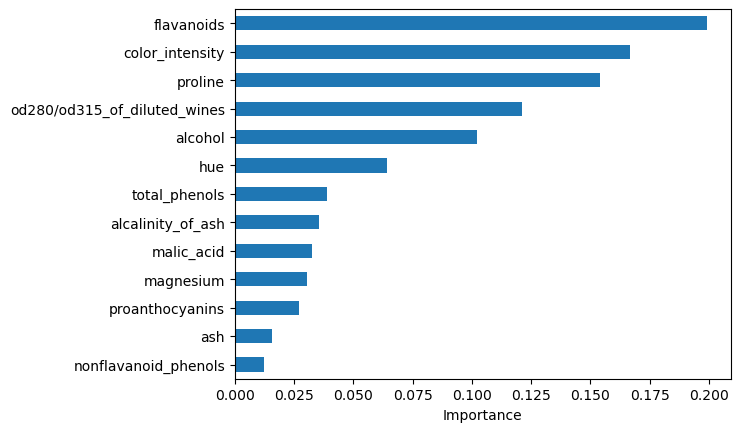

In [21]:
# Feature Importance 

import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=load_wine().feature_names
)

importance.sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Importance")
plt.show()

In [22]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [4, 8, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
0.9785714285714286


In [23]:
#Cross Validation 

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores.mean())

0.9665079365079364


In [25]:
# Handling Imbalanced Data

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

In [28]:
# Model Interpretation
%pip install shap
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.


   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ------- -------------------------------- 2.9/15.6 MB 18.6 MB/s eta 0:00:01
   --------------- ------------------------ 6.0/15.6 MB 14.2 MB/s eta 0:00:01
   ---------------------- ----------------- 8.7/15.6 MB 13.4 MB/s eta 0:00:01
   ---------------------------- ----------- 11.3/15.6 MB 13.0 MB/s eta 0:00:01
   ---------------------------------- ----- 13.6/15.6 MB 13.0 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.6 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 15.6/15.6 MB 12.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
Note: you may need to restart the kernel to use updated packages.


AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'